# Nested Spaces Visualization

Each child space applies the **same** TRS transform on top of its parent:
- Translate: (1, 0)
- Rotate: π/4 (45°)
- Scale: 1/√2 ≈ 0.707

Because the scale exactly cancels the rotation's diagonal, successive spaces
form a graceful spiral. We draw a small triangle in each local space,
then convert everything to absolute coordinates for plotting.


C:\Users\Emmanuel\AppData\Local\Temp\ipykernel_16812\1660262073.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl_cm.get_cmap("viridis")


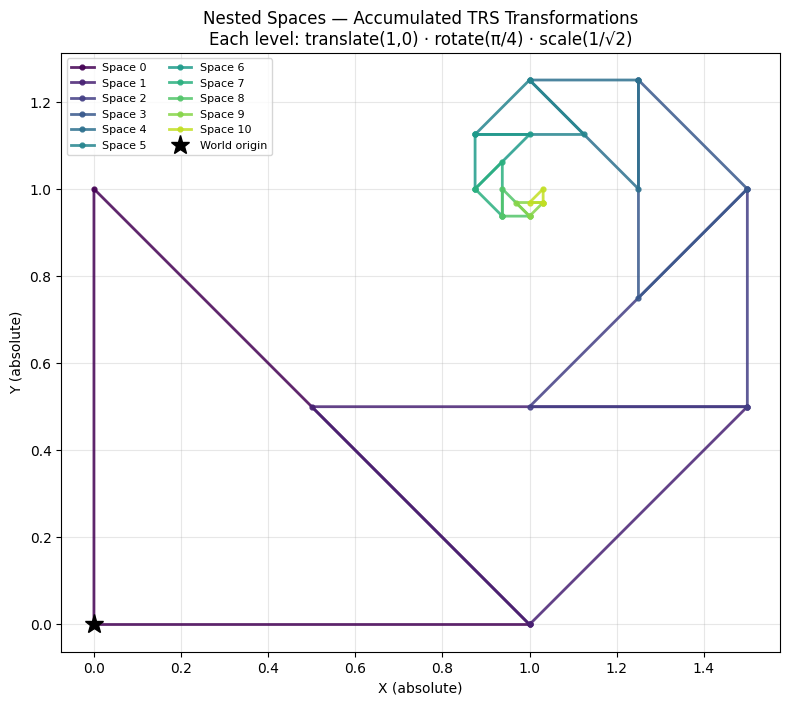

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
from coordinatus import Space2D, Point, create_space

# Root world space
root = Space2D()

# Build 10 nested child spaces, each with the same TRS
spaces = [root]
for _ in range(10):
    spaces.append(
        create_space(
            parent=spaces[-1],
            tx=1,
            ty=0,
            angle_rad=np.pi / 4,
            sx=1 / 2**0.5,
            sy=1 / 2**0.5,
        )
    )

# Local triangle corners (same in every space)
local_triangle = [(0, 0), (1, 0), (0, 1)]

fig, ax = plt.subplots(figsize=(8, 8))
cmap = mpl_cm.get_cmap("viridis")

for idx, space in enumerate(spaces):
    color = cmap(idx / len(spaces))
    abs_pts = [
        Point(np.array([x, y]), space=space).to_absolute().coords
        for x, y in local_triangle
    ]
    xs = [p[0] for p in abs_pts] + [abs_pts[0][0]]
    ys = [p[1] for p in abs_pts] + [abs_pts[0][1]]
    ax.plot(xs, ys, ".-", color=color, linewidth=2, markersize=7,
            label=f"Space {idx}", alpha=0.85)

ax.plot(0, 0, "k*", markersize=14, zorder=10, label="World origin")
ax.set_aspect("equal")
ax.set_xlabel("X (absolute)")
ax.set_ylabel("Y (absolute)")
ax.set_title(
    "Nested Spaces — Accumulated TRS Transformations\n"
    "Each level: translate(1,0) · rotate(π/4) · scale(1/√2)"
)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Key observations

- **Accumulated rotation**: each space is 45° further around.
- **Accumulated scale**: each space is ×(1/√2) smaller than its parent.
- **The spiral**: because the scale precisely compensates the distance added
  by the unit translation, origins converge toward a fixed point.
- **The triangle shrinks**: it gets smaller at every level because scale
  affects the local axes, not just the origin.


## Space hierarchy graph

`networkx` + `matplotlib` can render the parent-child tree of any set of `Space` objects.
The helper below walks up each space's `.parent` chain to build a directed graph, then lays it out as a tree.

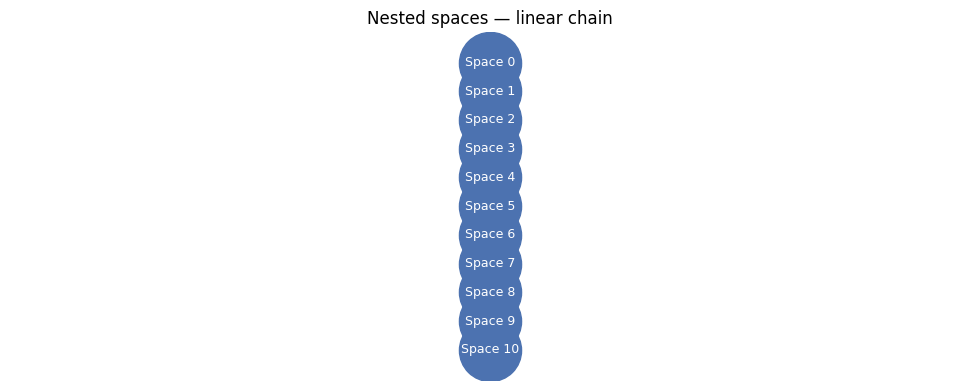

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt


def draw_space_hierarchy(spaces: list, labels: dict | None = None, title: str = "Space hierarchy") -> None:
    """Draw a directed tree of Space objects linked by their .parent attribute.

    Parameters
    ----------
    spaces:
        All Space objects to include in the graph.  Every object that is
        referenced as a parent must also be present in the list.
    labels:
        Optional mapping {space_id → display_label}.  If omitted, spaces are
        labelled "Space 0", "Space 1", … in the order they appear in *spaces*.
    title:
        Figure title.
    """
    if labels is None:
        labels = {id(s): f"Space {i}" for i, s in enumerate(spaces)}

    G = nx.DiGraph()
    for s in spaces:
        G.add_node(id(s))
        if s.parent is not None:
            G.add_edge(id(s.parent), id(s))   # parent → child

    # Hierarchical (top-down) layout via a simple BFS from roots
    def hierarchy_pos(G, root, width=1.0, vert_gap=1.0, x_start=0.0, depth=0, pos=None, parent=None):
        if pos is None:
            pos = {}
        children = [n for n in G.successors(root) if n != parent]
        if not children:
            pos[root] = (x_start, -depth * vert_gap)
        else:
            dx = width / len(children)
            next_x = x_start - width / 2 + dx / 2
            for child in children:
                hierarchy_pos(G, child, width=dx, vert_gap=vert_gap,
                              x_start=next_x, depth=depth + 1, pos=pos, parent=root)
                next_x += dx
            pos[root] = (x_start, -depth * vert_gap)
        return pos

    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    pos = {}
    x_offset = 0.0
    for root in roots:
        subtree_nodes = list(nx.dfs_preorder_nodes(G, root))
        subtree_width = max(1, sum(1 for n in subtree_nodes if G.out_degree(n) == 0))
        subtree_pos = hierarchy_pos(G, root, width=float(subtree_width), x_start=x_offset + subtree_width / 2)
        pos.update(subtree_pos)
        x_offset += subtree_width + 1

    node_labels = {n: labels.get(n, str(n)) for n in G.nodes}

    # Scale figure so nodes don't overlap: 1.2 units per level vertically
    depth = max(-y for _, y in pos.values()) if pos else 0
    width_units = x_offset or 1
    fig_w = max(5, width_units * 1.8)
    fig_h = max(3, (depth + 1) * 1.2)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    nx.draw(
        G, pos, ax=ax,
        labels=node_labels,
        with_labels=True,
        node_size=1800,
        node_color="#4C72B0",
        font_color="white",
        font_size=9,
        arrows=True,
        arrowsize=18,
        edge_color="#888888",
        width=2,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# --- Demo: the 10-level nested chain built above ---
draw_space_hierarchy(spaces, title="Nested spaces — linear chain")